# This notebook demonstrates the effect of initialization on UMAP embeddings

In [1]:
from pathlib import Path
import seaborn as sns
from matplotlib import pyplot as plt
import itertools
import pandas as pd
import numpy as np
import random
import umap

project_workdir = Path("/home/woodydrylab/DiskArray/b05b01002/project_umap_re/")
path_param_sets = project_workdir / "outputs/UMAP/param_table.csv"
path_seed_list = project_workdir / "outputs/UMAP/seeds.txt"

# class holding file paths
class PathFactory:
    def __init__(self, base):
        self._templates = {
            "ica": base / "outputs/InterClusterAngle/{sample}/seed{seed}.csv",
            "cluster": base / "outputs/Seurat/{sample}/clusters.csv",
            "pca": base / "outputs/Seurat/{sample}/pca.csv",
            "umap_embedding": base / "outputs/UMAP/{sample}/seed{seed}/param_set{param_set}.csv",
            "ica_aligned": base / (
                "outputs/InterClusterAngle/{sample}/per_{n}_embeddings/param_set{param_set}_median.csv"
            ),
            "aligned_rmsd": base / (
                "outputs/AlignEmbeddings/procrustes_alignment/{sample}/"
                "per_{n}_embeddings/param_set{param_set}/batch_{batch}/mean_rmsd.csv"
            ),
            "outdir": base / "notebooks/test-inits/"
        }

    @staticmethod
    def path_maker(template, **kwargs):
        template = str(template)
        for k, v in kwargs.items():
            template = template.replace("{"+ k +"}", str(v))
        return Path(template)

    def __getattr__(self, name):
        template = self._templates[name]
        return lambda **kwargs: PathFactory.path_maker(template, **kwargs)

paths = PathFactory(project_workdir)

# hyperparameters
metric = "cosine"
n_neighbors = 30
min_dist=0.3
n_epochs=500
init_methods=["spectral", "random", "pca", "tswspectral"]

# seeds
random.seed(42)
seed = random.sample(range(10**4, 10**5 -1), 1)[0]

# samples
sample = "ptr"

Read PCA embeddings

In [2]:
pca_embedding = pd.read_csv(paths.pca(sample=sample), index_col=0)
pca_embedding.head()

,PC_1,PC_2,PC_3,PC_4,PC_5,PC_6,PC_7,PC_8,PC_9,PC_10,...,PC_21,PC_22,PC_23,PC_24,PC_25,PC_26,PC_27,PC_28,PC_29,PC_30
AAACCTGAGCACCGCT-1,4.621016,2.024769,17.584276,-10.299449,15.338898,2.152367,2.154562,-7.481978,1.500189,-2.674422,...,-3.401414,-6.481636,-1.223386,-0.963346,4.003297,-3.886449,-4.647153,2.527880,-5.029293,0.990676
AAACCTGCAAGAGTCG-1,-39.570432,-13.367663,-2.659357,1.575751,0.733374,-2.506495,-0.617431,-1.492632,-0.019342,-1.657764,...,-0.360465,-1.146610,-1.280875,0.258915,2.156610,-1.686862,0.870908,0.714890,-1.719078,4.248097
AAACCTGCACATTCGA-1,15.385023,-13.359174,-4.970484,6.690829,6.323053,-1.932433,2.696401,2.078874,-0.026331,0.062150,...,4.138510,-3.108941,-0.989197,2.266912,0.004443,0.426774,1.929810,4.419674,1.562777,0.676641
AAACCTGGTAAATGAC-1,14.513186,-14.591126,-8.840470,3.379132,4.952565,-1.381813,4.082260,5.420280,0.735005,1.190764,...,-1.254728,-3.256410,-0.164974,1.548979,-3.950572,1.722404,0.343092,0.705338,2.159522,-1.958113
AAACCTGGTCATCGGC-1,-5.916135,10.138170,-5.011105,7.706331,1.162036,0.881359,3.099613,1.223004,6.015965,1.799663,...,-1.733831,-1.054806,1.016583,-2.149549,1.384676,1.076933,3.550263,-0.323664,0.443436,5.382004


Read cluster df

In [3]:
cluster = pd.read_csv(
    paths.cluster(sample=sample),
    index_col=0,
    header=0,
    dtype=str,
    names=["cluster"]
)
cluster.head()

,cluster
AAACCTGAGCACCGCT-1,2
AAACCTGCAAGAGTCG-1,5
AAACCTGCACATTCGA-1,0
AAACCTGGTAAATGAC-1,0
AAACCTGGTCATCGGC-1,1


In [4]:
embeddings = {}
for init_method in init_methods:
    mapper = umap.UMAP(
        random_state=seed,
        metric=metric,
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        n_epochs=n_epochs,
        init=init_method
    )
    embeddings[init_method] = mapper.fit_transform(pca_embedding.values)

/home/woodydrylab/DiskArray/b05b01002/conda_env/python-dev/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/woodydrylab/DiskArray/b05b01002/conda_env/python-dev/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/woodydrylab/DiskArray/b05b01002/conda_env/python-dev/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/woodydrylab/DiskArray/b05b01002/conda_env/python-dev/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


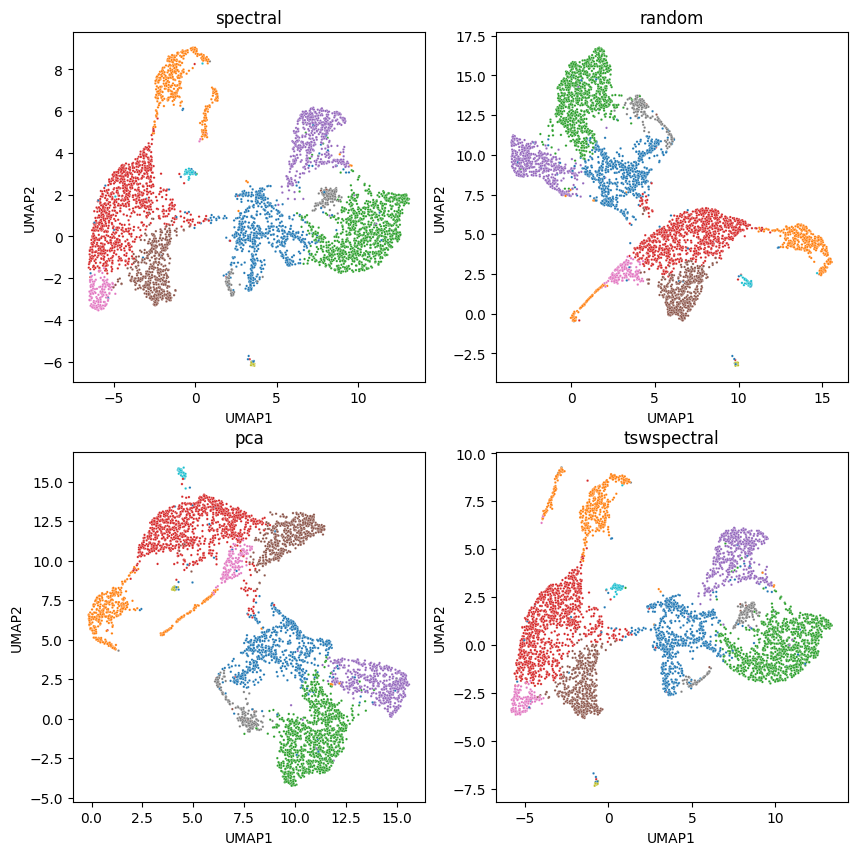

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
for init_method, ax in zip(init_methods, axes.flatten()):
    data = pd.DataFrame(embeddings[init_method])
    data.columns = ["UMAP1", "UMAP2"]
    data["cluster"] = cluster["cluster"].values
    sns.scatterplot(
        data=data,
        x="UMAP1",
        y="UMAP2",
        hue="cluster",
        ax=ax,
        legend=False,
        s=3
    )
    ax.set_title(init_method)

fig.savefig("test_inits.png")